Resolved inputs:
  model_path: /home/suzuki/Projects/scDiffusion/output/diffusion_checkpoint_soft_hvg1024_20251127_005/pbmc68k_soft_20251127_hvg1024/model003000.pt
  sample_path: /home/suzuki/Projects/scDiffusion/output/simulated_samples/pbmc68k_soft_20251127_hvg1024_3000steps_500samples_20251218_055809.npz
  loss_path: /home/suzuki/Projects/scDiffusion/output/diffusion_checkpoint_soft_hvg1024_20251127_005/pbmc68k_soft_20251127_hvg1024/loss_details.csv
  viz_dir: /home/suzuki/Projects/scDiffusion/exp_script/pbmc68k_soft_20251127_hvg1024_3000steps_20251218_061113

Showing: /home/suzuki/Projects/scDiffusion/exp_script/pbmc68k_soft_20251127_hvg1024_3000steps_20251218_061113/loss_curves.png


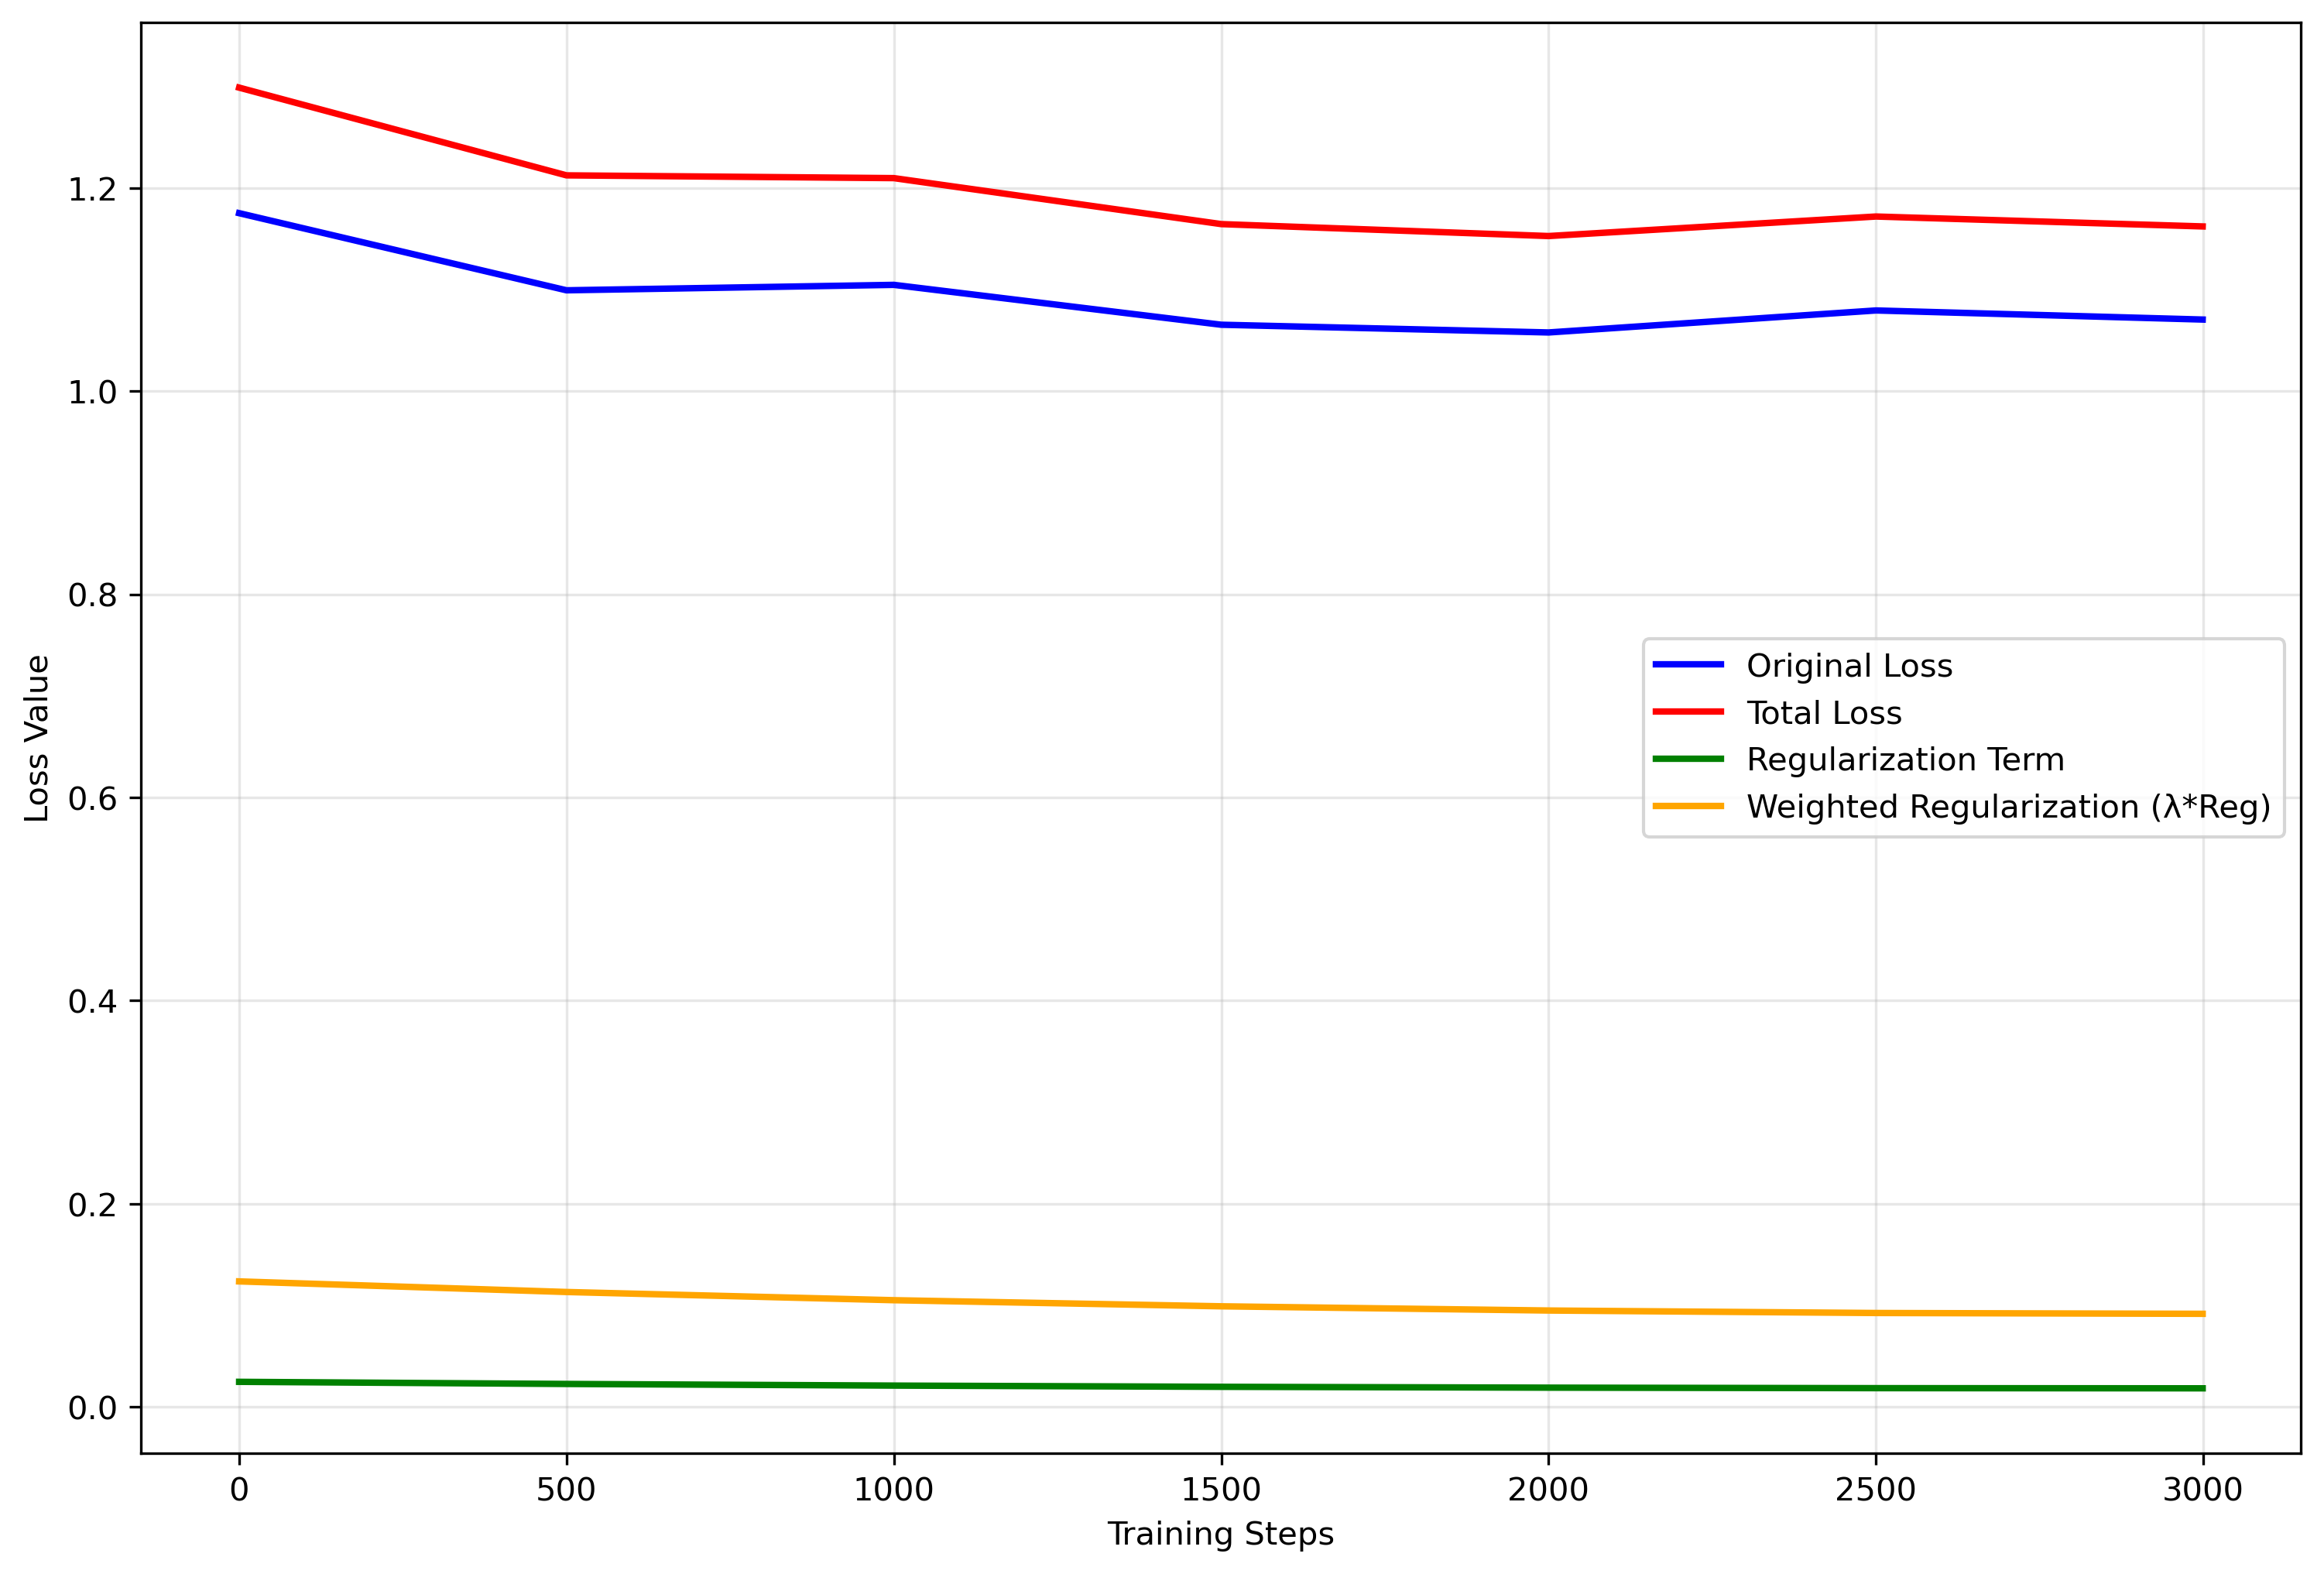


Showing: /home/suzuki/Projects/scDiffusion/exp_script/pbmc68k_soft_20251127_hvg1024_3000steps_20251218_061113/parameter_distributions.png


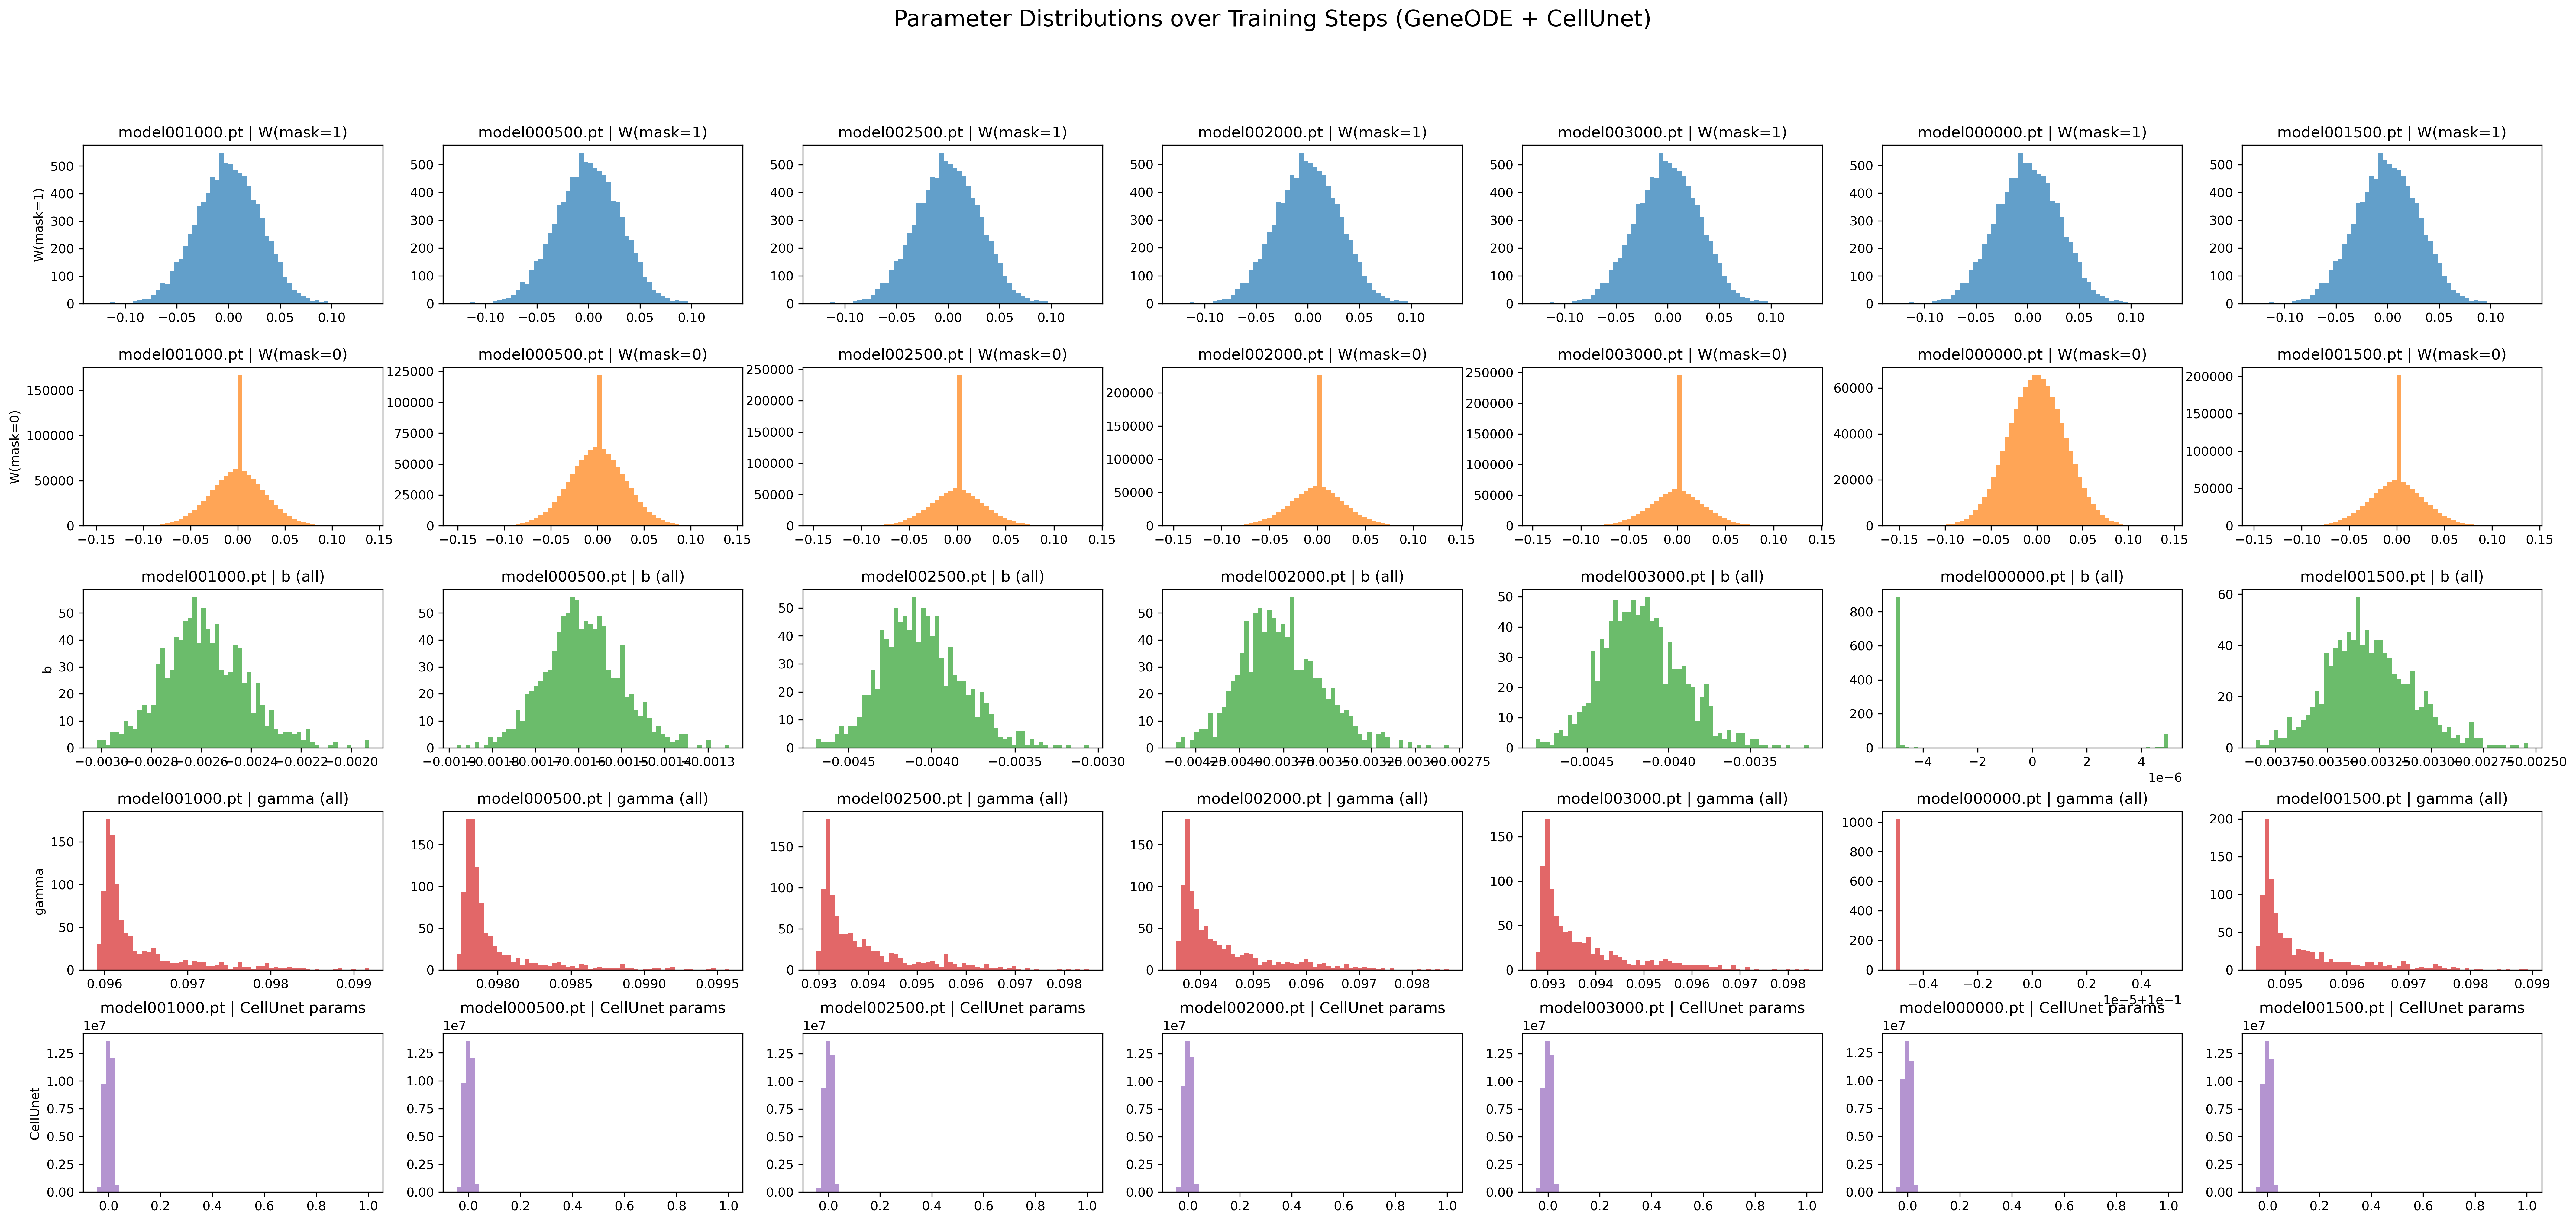


Showing: /home/suzuki/Projects/scDiffusion/exp_script/pbmc68k_soft_20251127_hvg1024_3000steps_20251218_061113/gene_correlation.png


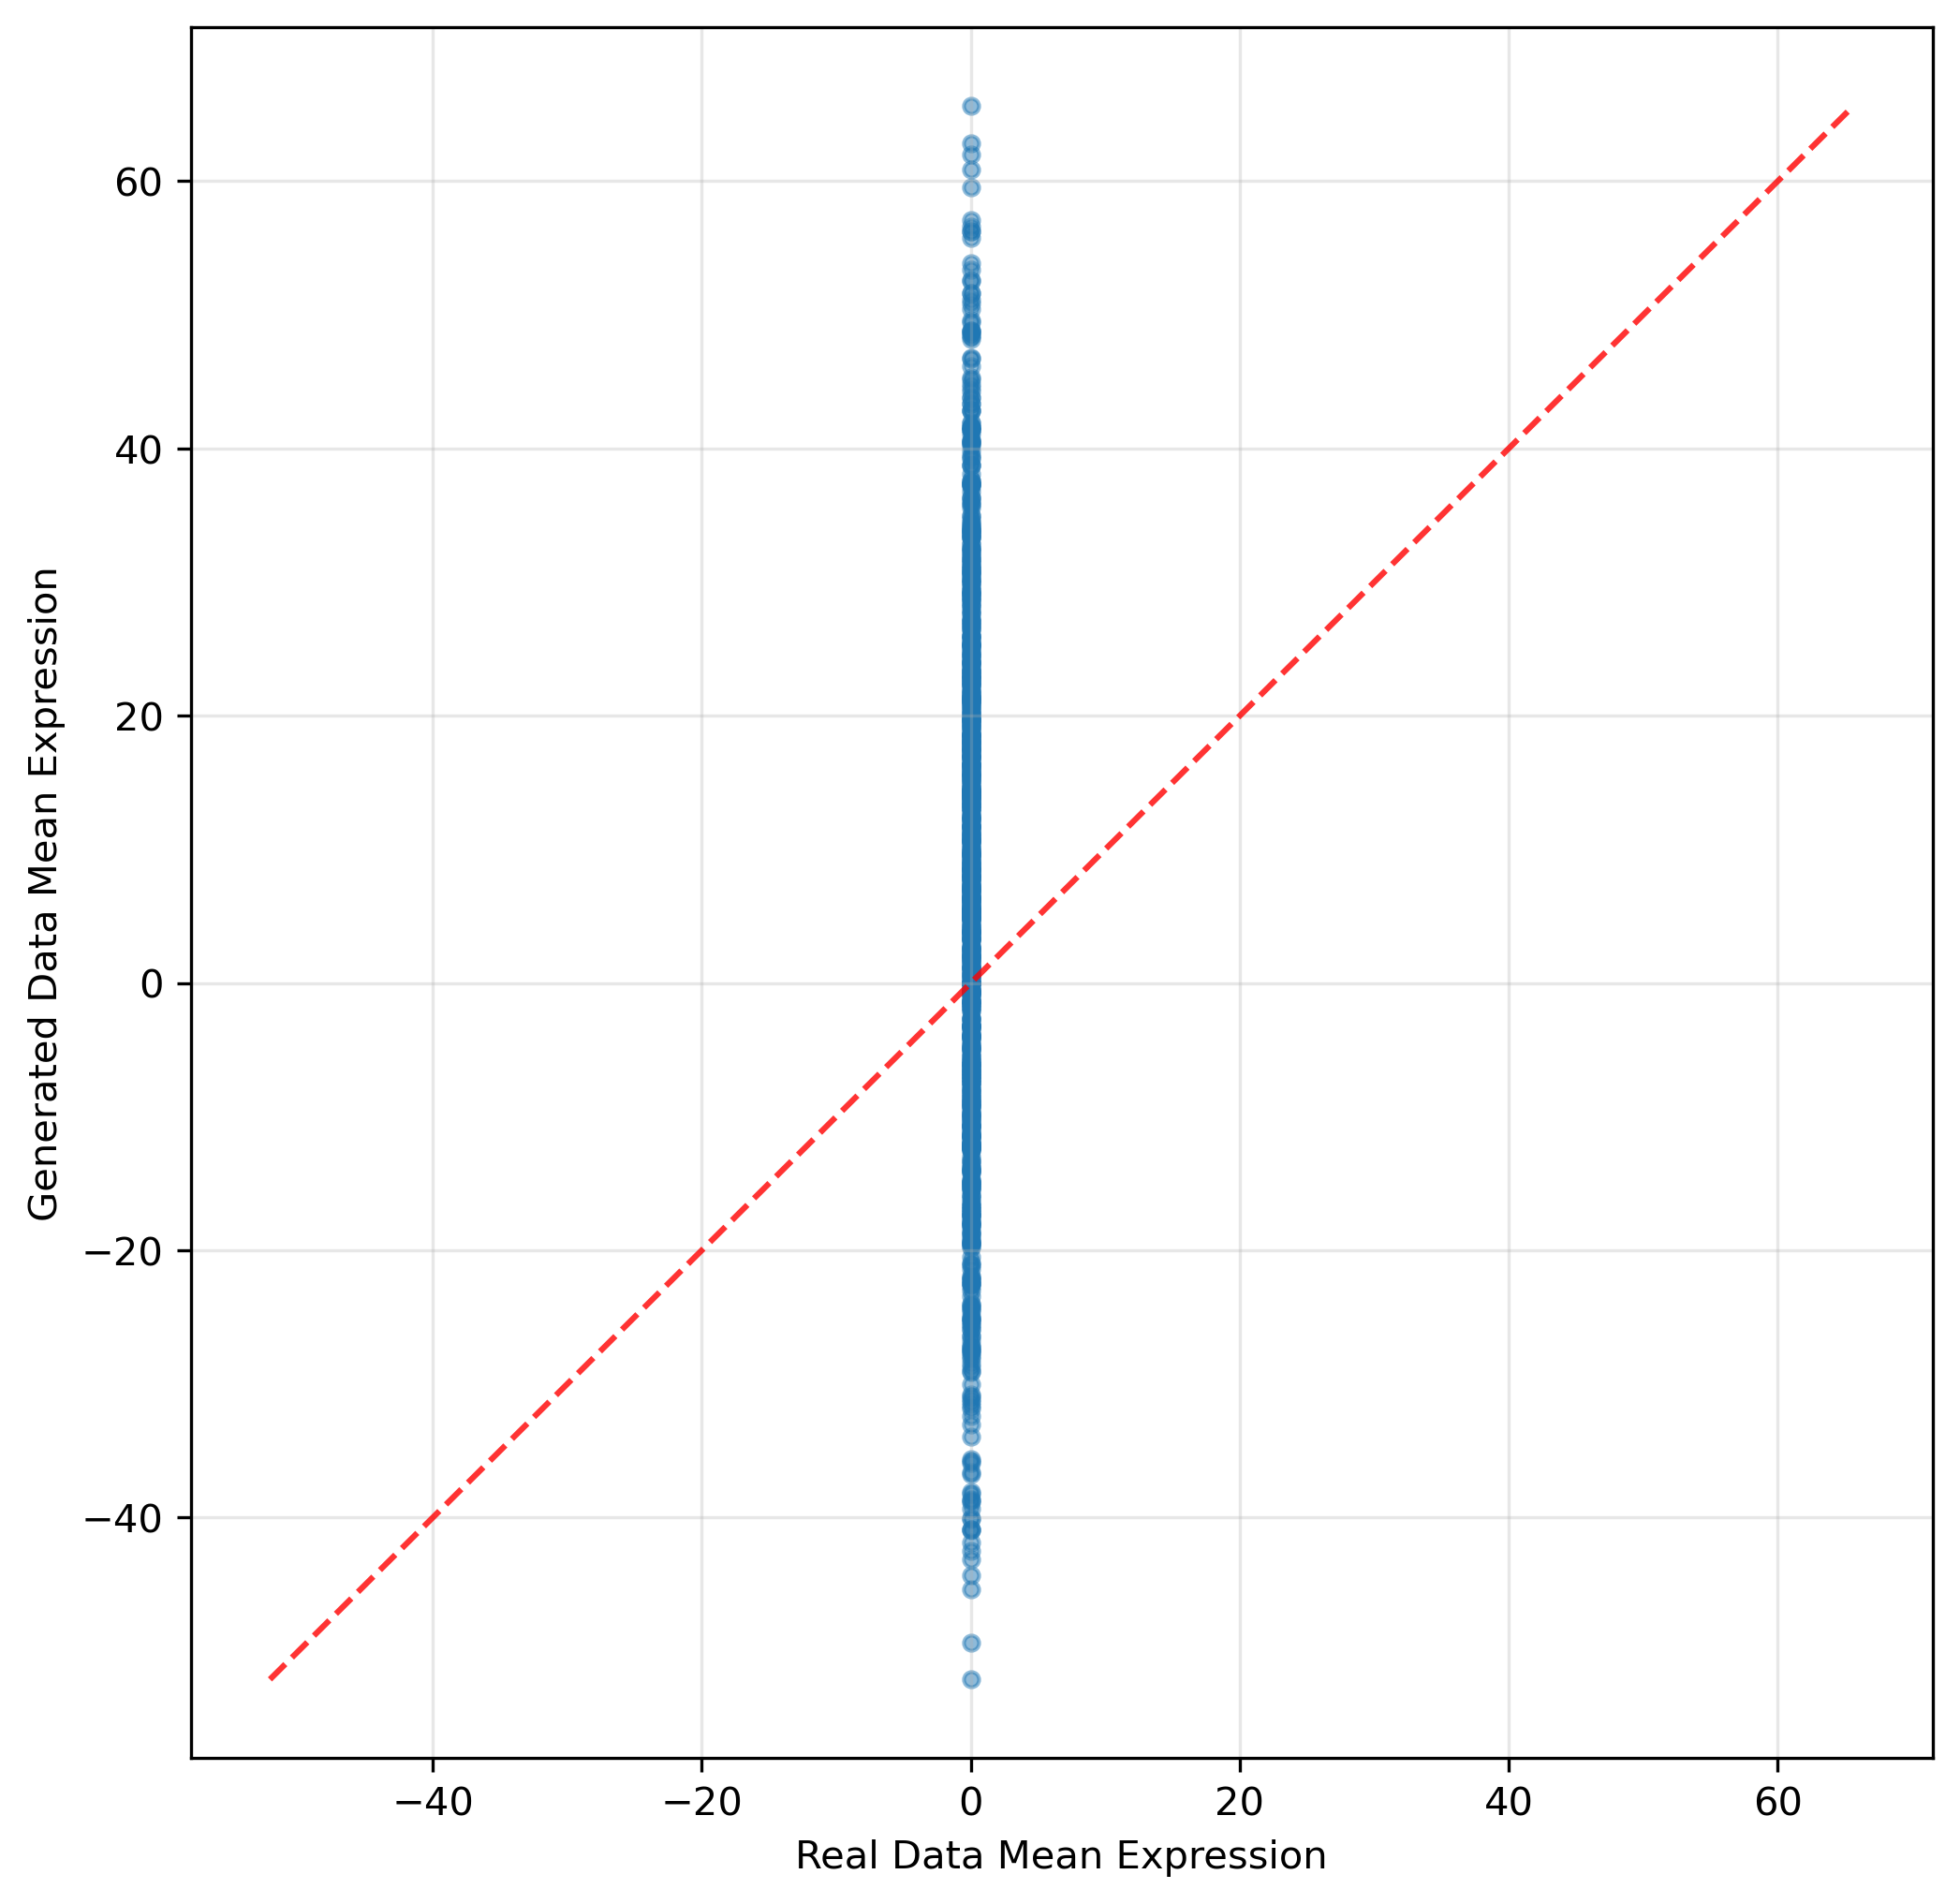


Showing: /home/suzuki/Projects/scDiffusion/exp_script/pbmc68k_soft_20251127_hvg1024_3000steps_20251218_061113/umap_analysis.png


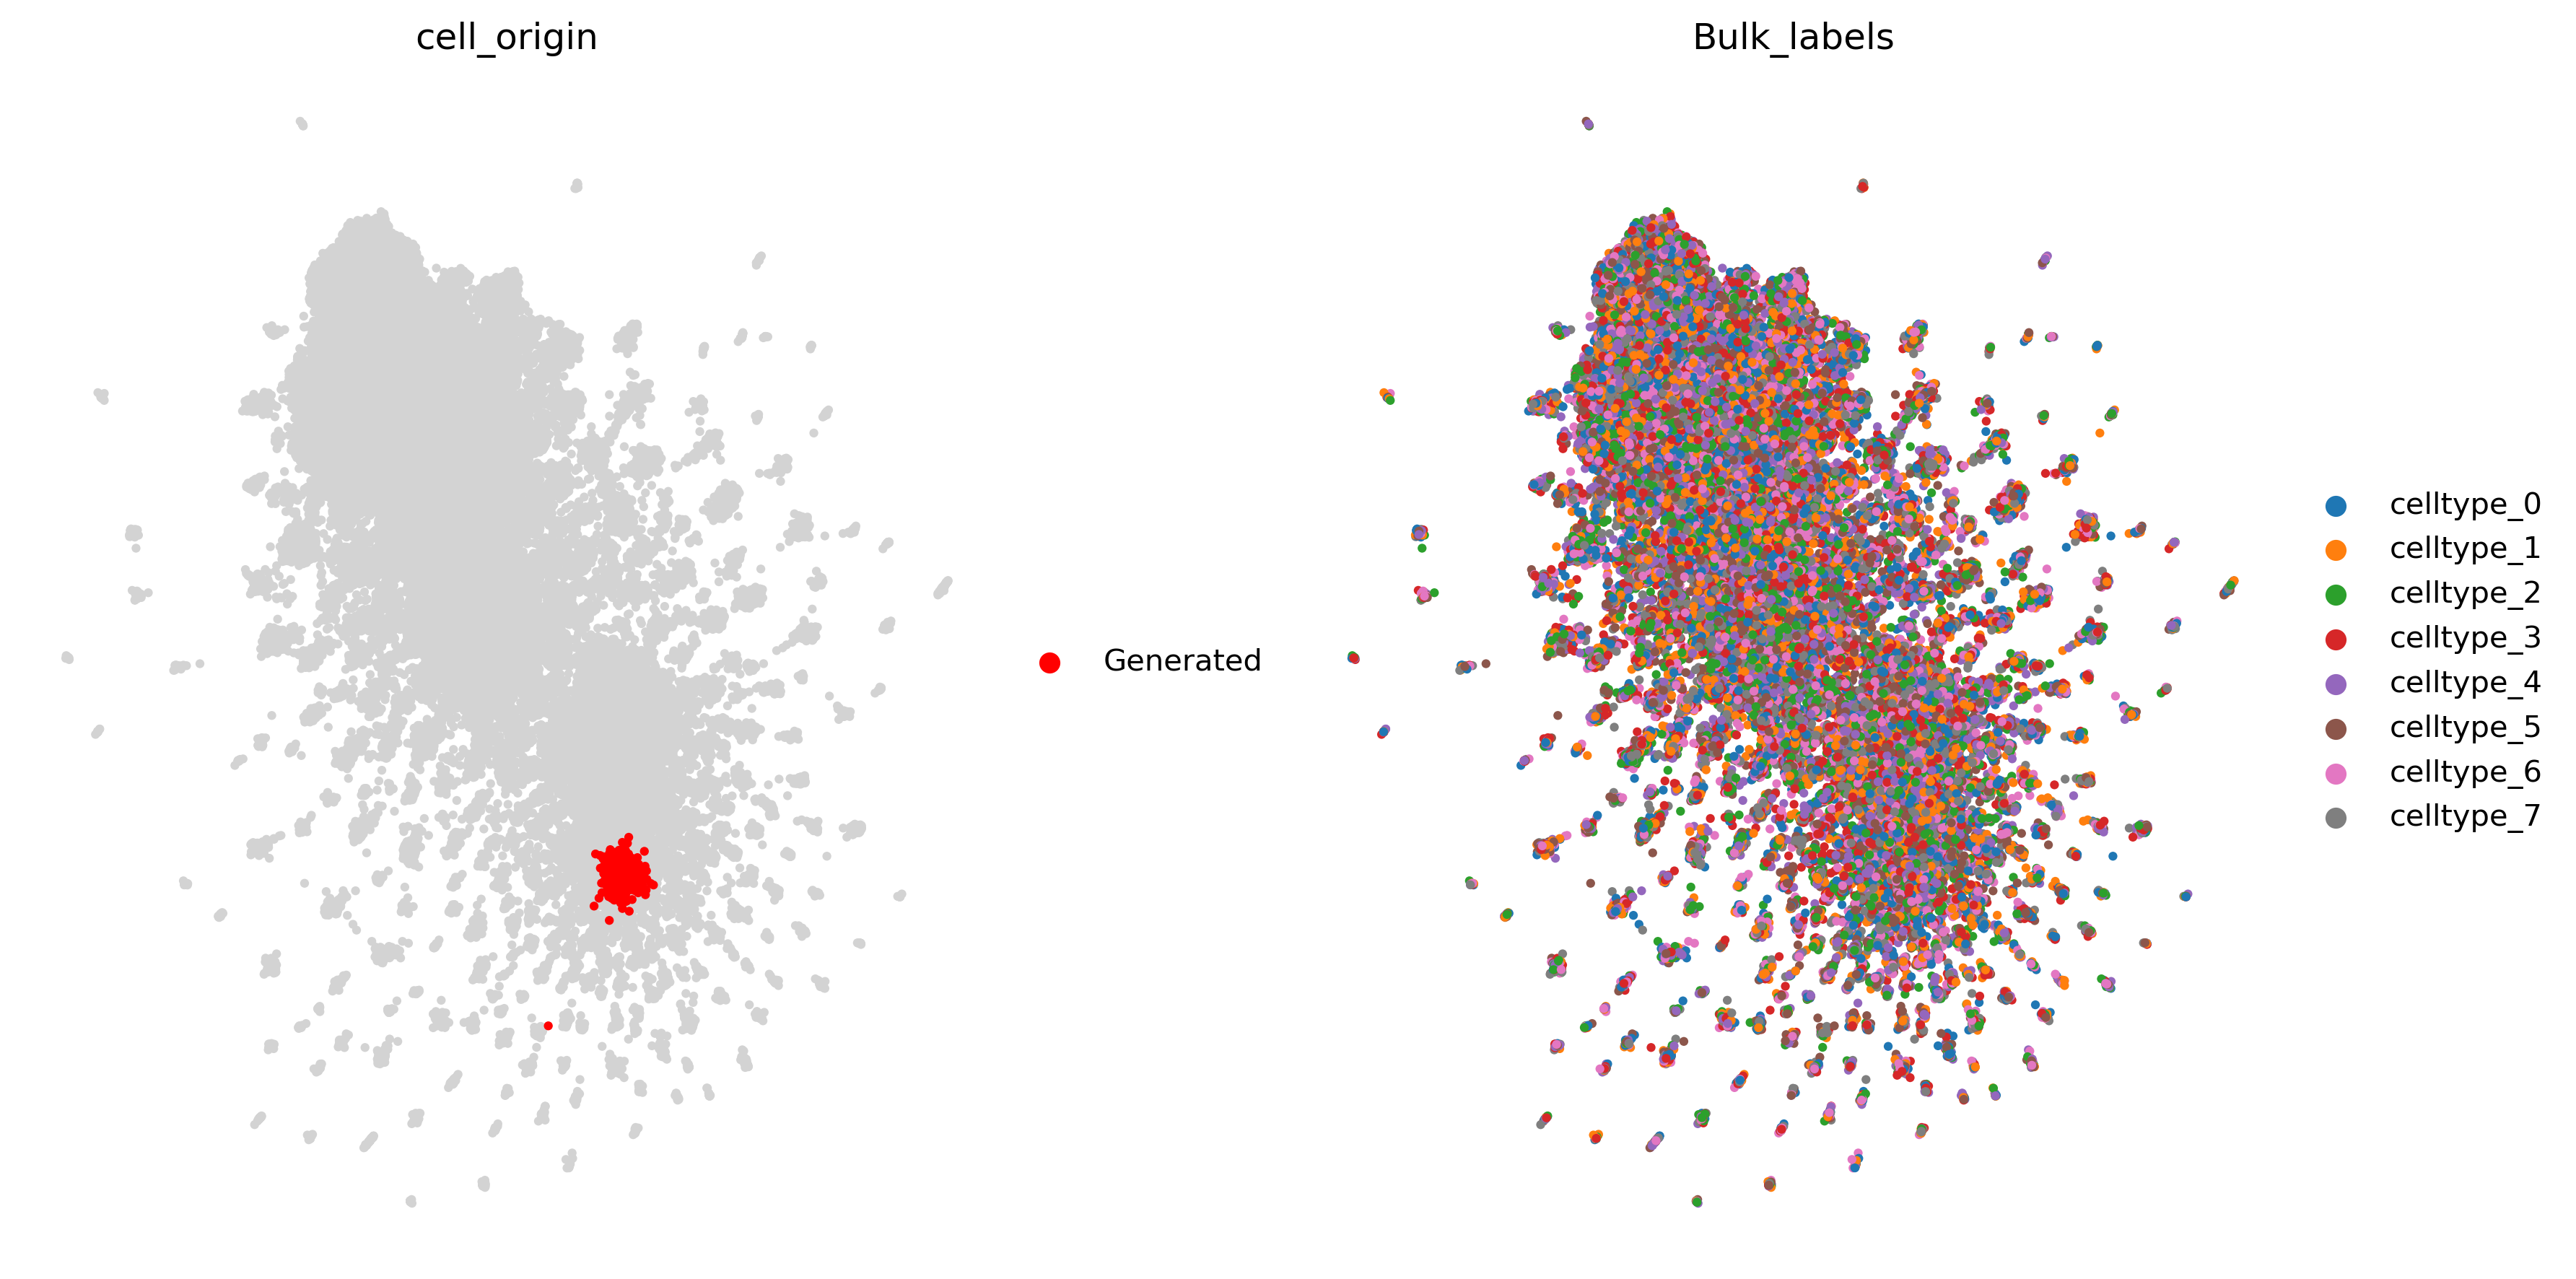

In [1]:
# Auto-loaded visualization context for this run
# Reads analysis_metadata.txt and displays saved plots
import os, re
from pathlib import Path
from IPython.display import display, Image

# Base directory for this run (update if moving notebook)
base_dir = Path("/home/suzuki/Projects/scDiffusion/exp_script/pbmc68k_soft_20251127_hvg1024_3000steps_20251218_061113")
meta_path = base_dir / "analysis_metadata.txt"

# Parse metadata
meta = {}
if meta_path.exists():
    for line in meta_path.read_text().splitlines():
        if ":" in line:
            k, v = line.split(":", 1)
            meta[k.strip()] = v.strip()
else:
    print(f"Metadata not found: {meta_path}")

# Resolve paths (metadata may contain relative paths)
proj_root = Path("/home/suzuki/Projects/scDiffusion")
model_path = meta.get("Model Path")
sample_path = meta.get("Sample Path")
loss_path = meta.get("Loss Details Path")

if model_path and not model_path.startswith("/"):
    model_path = str((proj_root / model_path).resolve())
if sample_path and not sample_path.startswith("/"):
    sample_path = str((proj_root / sample_path).resolve())
if loss_path and not loss_path.startswith("/"):
    loss_path = str((proj_root / loss_path).resolve())

print("Resolved inputs:")
print("  model_path:", model_path)
print("  sample_path:", sample_path)
print("  loss_path:", loss_path)
print("  viz_dir:", str(base_dir))

# Display generated plots if present
imgs = [
    base_dir / "loss_curves.png",
    base_dir / "parameter_distributions.png",
    base_dir / "gene_correlation.png",
    base_dir / "umap_analysis.png",
]
for p in imgs:
    if p.exists():
        print(f"\nShowing: {p}")
        display(Image(filename=str(p)))
    else:
        print(f"Missing (skip): {p}")


In [2]:
# GPU availability check
import torch
import sys

print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("Number of GPUs:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB")
    print("Current device:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name())
else:
    print("CUDA is not available")
    print("Available devices:", "CPU only")

Python version: 3.9.22 | packaged by conda-forge | (main, Apr 14 2025, 23:35:59) 
[GCC 13.3.0]
PyTorch version: 2.5.1
CUDA available: True
CUDA version: 12.1
Number of GPUs: 1
GPU 0: NVIDIA RTX 6000 Ada Generation
  Memory: 47.4 GB
Current device: 0
Device name: NVIDIA RTX 6000 Ada Generation


# PBMC68k Soft Constraint Diffusion Analysis - HVG 1024 version (20251106)

# Copied and updated for soft20251106_hvg1024

This script analyzes the generated samples from the pbmc68k_soft20251106_hvg1024 model.

## Overview
- Dataset: PBMC68k
- Model: Soft Constraint Diffusion (HVG=1024 genes)
- Date: 2025-11-06

In [5]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import sys
import warnings
warnings.filterwarnings('ignore')

# Set up scanpy settings
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white')

print("Environment set up successfully!")

Environment set up successfully!


## Load Real Data

In [6]:
# Load PBMC68k dataset and apply same preprocessing as in cell_train_soft20251105_reg005_hvg1024.py
adata = sc.read_h5ad('/home/suzuki/Projects/scDiffusion/data_preparation/pbmc68k_preprocessed_zscore_hvg1024_20251105.h5ad')


In [16]:
# Load PBMC68k dataset and apply same preprocessing as in cell_train_soft20251105_reg005_hvg1024.py
test = sc.read_h5ad("/home/suzuki/Projects/scDiffusion/data_preparation/data/Pancreas/endocrinogenesis_day15.h5ad")


In [21]:
import pyreadr, pandas as pd
res = pyreadr.read_r('/home/suzuki/Projects/scDiffusion/external_data/gr_network_human_21122021.rds')
gr_df = res[None]   

In [22]:
gr_df

,from,to,source,database
0,KLF2,DLGAP1,harmonizome_CHEA,harmonizome_gr
1,KLF2,DTNB,harmonizome_CHEA,harmonizome_gr
2,KLF2,BHLHE40,harmonizome_CHEA,harmonizome_gr
3,KLF2,RPS6KA1,harmonizome_CHEA,harmonizome_gr
4,KLF2,PXN,harmonizome_CHEA,harmonizome_gr
...,...,...,...,...
5870445,H2BC10,ITGA2B,pathwaycommons_controls_expression_of,pathwaycommons_expression
5870446,H2BC10,KDM4B,pathwaycommons_controls_expression_of,pathwaycommons_expression
5870447,H2BC10,KLK2,pathwaycommons_controls_expression_of,pathwaycommons_expression
5870448,H2BC10,KLK3,pathwaycommons_controls_expression_of,pathwaycommons_expression


In [23]:
test.var.index

Index(['Xkr4', 'Gm37381', 'Rp1', 'Rp1-1', 'Sox17', 'Gm37323', 'Mrpl15',
       'Rgs20', 'Npbwr1', '4732440D04Rik',
       ...
       'Gm28406', 'Gm29436', 'Gm28407', 'Gm29393', 'Gm21294', 'Gm28672',
       'Gm28670', 'Gm29504', 'Gm20837', 'Erdr1'],
      dtype='object', name='index', length=27998)

In [24]:
# test.var.index が Index だとする
mask = test.var.index.isin(gr_df["from"])
count = mask.sum()
ratio = count / len(test.var.index)

print(count, ratio)
print(f"Number of genes in GR network: {count} out of {len(test.var.index)} ({ratio:.2%})")

10 0.0003571683691692264
Number of genes in GR network: 10 out of 27998 (0.04%)


In [26]:
adata

AnnData object with n_obs × n_vars = 68579 × 1024
    obs: 'TSNE.1', 'TSNE.2', 'celltype', 'n_genes'
    var: 'gene_id', 'gene_name', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p'

In [27]:
# Prepare cell type labels
print('Data shape:', adata.shape)
print('Cell types in dataset:')
print(adata.obs['celltype'].value_counts())

Data shape: (68579, 1024)
Cell types in dataset:
celltype
CD8+ Cytotoxic T                20773
CD8+/CD45RA+ Naive Cytotoxic    16666
CD56+ NK                         8776
CD4+/CD25 T Reg                  6187
CD19+ B                          5908
CD4+/CD45RO+ Memory              3061
CD14+ Monocyte                   2862
Dendritic                        2099
CD4+/CD45RA+/CD25- Naive T       1873
CD34+                             277
CD4+ T Helper2                     97
Name: count, dtype: int64


## Load Generated Data from Soft Constraint Model

In [1]:
import numpy as np
import os

# Path to the HVG 1024 version generated samples from soft constraint model
unconditional_path = "/home/suzuki/Projects/scDiffusion/output/simulated_samples/pbmc68k_soft_20251127_hvg1024_10000steps_2000samples_20251218_084641.npz"

print(f"Loading generated samples from: {unconditional_path}")

try:
    # Load generated data
    if os.path.exists(unconditional_path):
        npzfile = np.load(unconditional_path, allow_pickle=True)
        print(f"Available keys in npz file: {list(npzfile.keys())}")
        
        # Extract generated cell data
        cell_gen = npzfile['cell_gen']  # Assuming this is the key for generated cells
        print(f"Generated samples shape: {cell_gen.shape}")
        print(f"Number of generated samples: {cell_gen.shape[0]}")
        print(f"Number of genes: {cell_gen.shape[1]} (HVG 1024)")
        
        # Verify this matches our HVG processing
        if cell_gen.shape[1] == 1024:
            print("✓ Generated data has correct number of HVG genes (1024)")
        else:
            print(f"⚠ Warning: Expected 1024 genes, but got {cell_gen.shape[1]}")
        
        npzfile.close()
        
        print(f"Final generated samples shape: {cell_gen.shape}")
    else:
        print("Failed to load generated samples")
        
except FileNotFoundError:
    print(f"Generated samples file not found at: {unconditional_path}")
    print("Please check if the pbmc68k_soft_20251106_hvg1024_500samples.npz file exists")
except Exception as e:
    print(f"Error loading generated samples: {e}")

Loading generated samples from: /home/suzuki/Projects/scDiffusion/output/simulated_samples/pbmc68k_soft_20251127_hvg1024_10000steps_2000samples_20251218_084641.npz
Available keys in npz file: ['cell_gen']
Generated samples shape: (2000, 1024)
Number of generated samples: 2000
Number of genes: 1024 (HVG 1024)
✓ Generated data has correct number of HVG genes (1024)
Final generated samples shape: (2000, 1024)


In [7]:
# Analyze generated samples - HVG 1024 soft constraint version (20251106)
# Visualization for HVG=1024 soft constraint (20251106)

if 'cell_gen' in locals() and cell_gen is not None:
    print("Processing generated samples for analysis...")
    
    # Create AnnData object from generated samples
    import anndata
    
    # Create AnnData object for generated samples
    adata_gen = anndata.AnnData(cell_gen)
    adata_gen.var_names = adata.var_names  # Use same gene names as original
    print(f"Generated AnnData shape: {adata_gen.shape}")
    
    # Basic statistics of generated samples
    print(f"\nGenerated samples statistics:")
    print(f"Mean expression: {np.mean(cell_gen):.4f}")
    print(f"Std expression: {np.std(cell_gen):.4f}")
    print(f"Min expression: {np.min(cell_gen):.4f}")
    print(f"Max expression: {np.max(cell_gen):.4f}")
    
    # Compare with original data statistics  
    print(f"\nOriginal data statistics:")
    print(f"Mean expression: {np.mean(adata.X):.4f}")
    print(f"Std expression: {np.std(adata.X):.4f}")
    print(f"Min expression: {np.min(adata.X):.4f}")
    print(f"Max expression: {np.max(adata.X):.4f}")
    
    # Check for any infinite or NaN values
    print(f"\nData quality check:")
    print(f"Generated - Contains NaN: {np.any(np.isnan(cell_gen))}")
    print(f"Generated - Contains Inf: {np.any(np.isinf(cell_gen))}")
    print(f"Original - Contains NaN: {np.any(np.isnan(adata.X))}")
    print(f"Original - Contains Inf: {np.any(np.isinf(adata.X))}")
    
    # Store for downstream analysis
    print("\n✓ Generated samples processed and ready for analysis")
    
else:
    print("Generated samples not available. Please load them first.")

Processing generated samples for analysis...
Generated AnnData shape: (2000, 1024)

Generated samples statistics:
Mean expression: 0.5560
Std expression: 3.9900
Min expression: -26.3268
Max expression: 25.5256

Original data statistics:
Mean expression: 0.0000


Std expression: 1.0000
Min expression: -8.2930
Max expression: 231.5337

Data quality check:
Generated - Contains NaN: False
Generated - Contains Inf: False
Original - Contains NaN: False
Original - Contains Inf: False

✓ Generated samples processed and ready for analysis


In [8]:
# Get gene expression data (already log-normalized)
if hasattr(adata.X, 'toarray'):
    cell_data = adata.X.toarray()
else:
    cell_data = adata.X

## Gene Expression Correlation Analysis

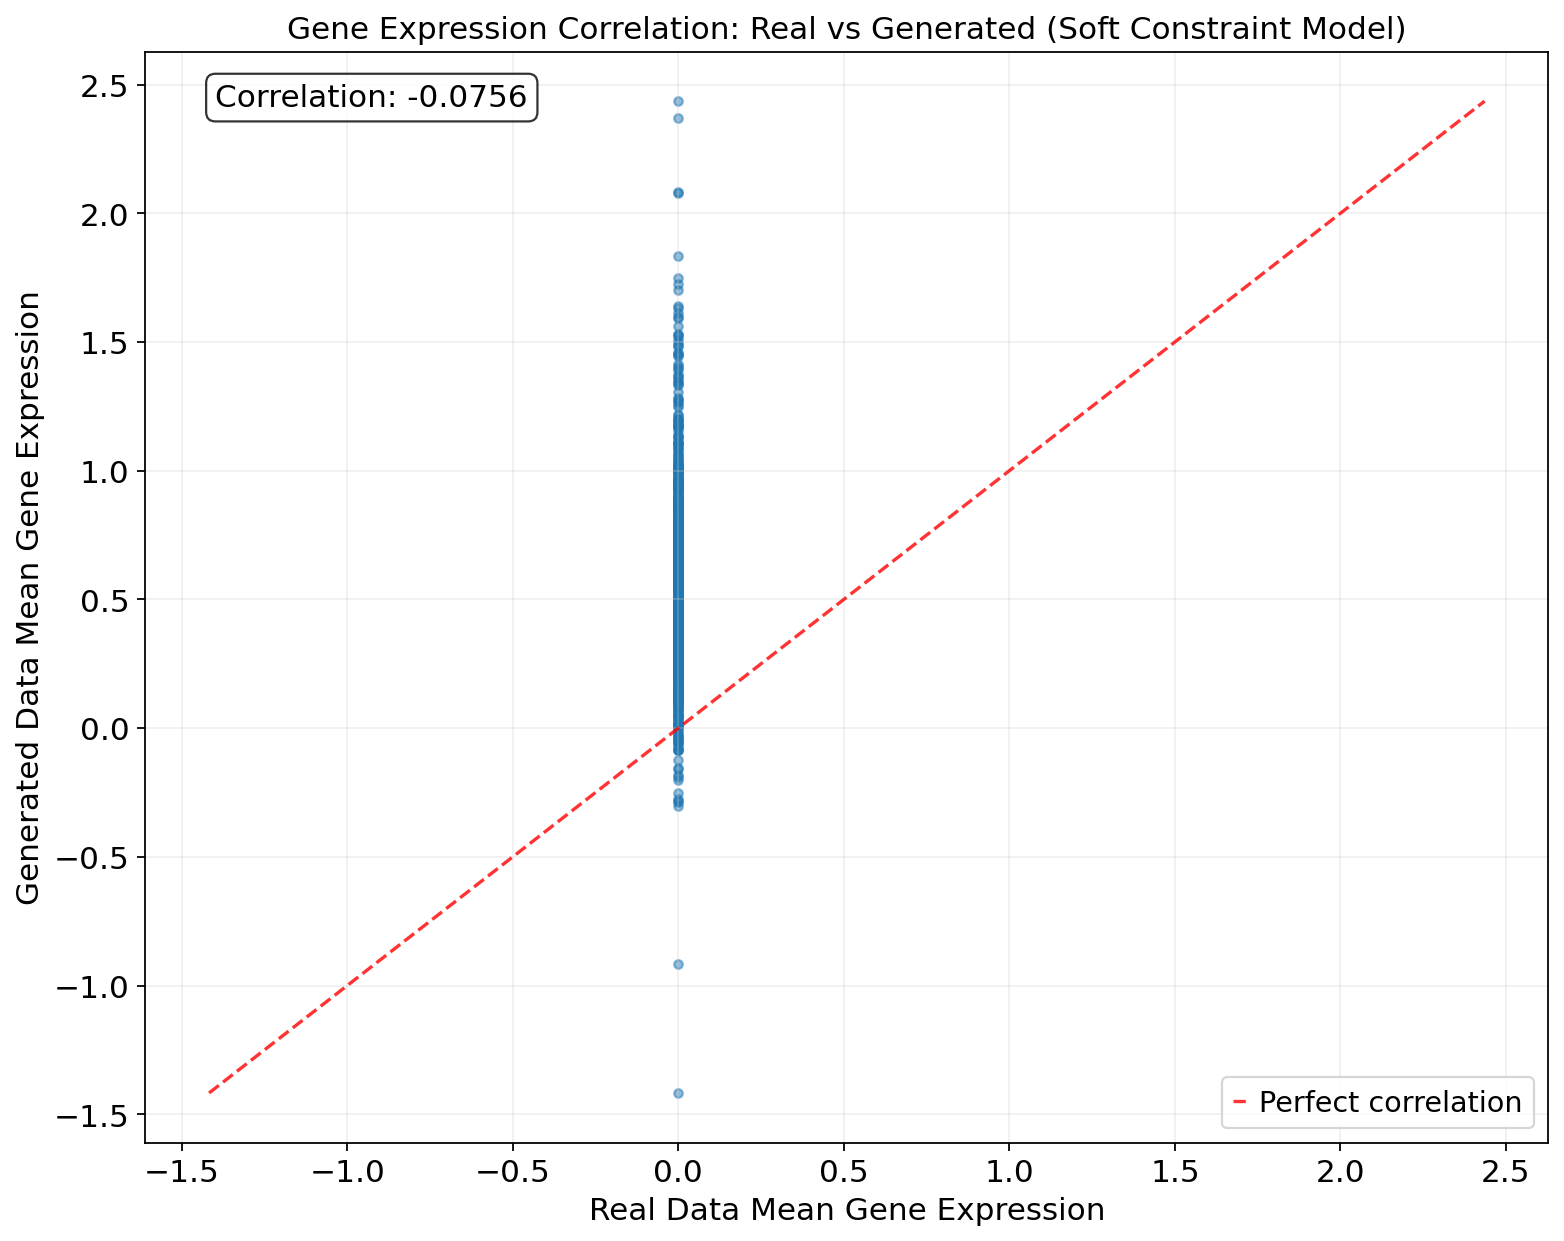

Soft constraint model generation correlation: -0.0756


In [9]:
# Analyze gene expression correlation between real and generated data
if cell_gen is not None:
    # Calculate mean expression per gene
    real_gene_means = cell_data.mean(axis=0)
    gen_gene_means = cell_gen.mean(axis=0)
    
    # Plot correlation
    plt.figure(figsize=(10, 8))
    plt.scatter(real_gene_means, gen_gene_means, alpha=0.5, s=15)
    plt.xlabel('Real Data Mean Gene Expression')
    plt.ylabel('Generated Data Mean Gene Expression')
    plt.title('Gene Expression Correlation: Real vs Generated (Soft Constraint Model)')
    
    # Add diagonal line
    min_val = min(real_gene_means.min(), gen_gene_means.min())
    max_val = max(real_gene_means.max(), gen_gene_means.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, label='Perfect correlation')
    
    # Calculate correlation
    corr_coef = np.corrcoef(real_gene_means, gen_gene_means)[0, 1]
    plt.text(0.05, 0.95, f'Correlation: {corr_coef:.4f}', transform=plt.gca().transAxes, 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Soft constraint model generation correlation: {corr_coef:.4f}")
else:
    print("No generated data available for correlation analysis")

In [10]:
# Create AnnData object for UMAP analysis
print("Creating combined dataset for UMAP analysis...")

if cell_gen is not None:
    # Combine real and generated data
    combined_data = np.concatenate((cell_data, cell_gen), axis=0)
    print(f"Combined data shape: {combined_data.shape}")
    
    # Create cell origin labels
    n_real = cell_data.shape[0]
    n_gen = cell_gen.shape[0]
    cell_origin = ['Real'] * n_real + ['Generated'] * n_gen
    
    # Create AnnData object
    adata_combined = sc.AnnData(X=combined_data)
    adata_combined.obs['cell_origin'] = cell_origin
    
    # Add real cell type information
    real_celltypes = adata.obs['celltype'].values
    all_celltypes = list(real_celltypes) + ['Generated'] * n_gen
    adata_combined.obs['celltype'] = all_celltypes
    
    print(f"AnnData object created: {adata_combined.shape}")
    print(f"Cell origin distribution: {adata_combined.obs['cell_origin'].value_counts()}")
    
else:
    print("Error: Generated data not available")

Creating combined dataset for UMAP analysis...
Combined data shape: (70579, 1024)
AnnData object created: (70579, 1024)
Cell origin distribution: cell_origin
Real         68579
Generated     2000
Name: count, dtype: int64


In [11]:
# Run UMAP preprocessing and analysis
print("Running UMAP analysis...")

if 'adata_combined' in locals():
    # Basic preprocessing for UMAP
    print("Scaling data...")
    sc.pp.scale(adata_combined, max_value=10)
    
    print("Running PCA...")
    sc.tl.pca(adata_combined, svd_solver='arpack', n_comps=50)
    
    print("Computing neighbors...")
    sc.pp.neighbors(adata_combined, n_neighbors=15, n_pcs=40)
    
    print("Computing UMAP...")
    sc.tl.umap(adata_combined)
    
    print("UMAP computation completed!")
    print(f"UMAP coordinates shape: {adata_combined.obsm['X_umap'].shape}")
    
else:
    print("Error: Combined data not available")

Running UMAP analysis...
Scaling data...


Running PCA...
computing PCA
    with n_comps=50
    finished (0:00:30)
Computing neighbors...
computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:01:26)
Computing UMAP...
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:02:36)
UMAP computation completed!
UMAP coordinates shape: (70579, 2)


## UMAP Visualization: Real vs Generated (Soft Constraint Model)

Creating UMAP visualizations...


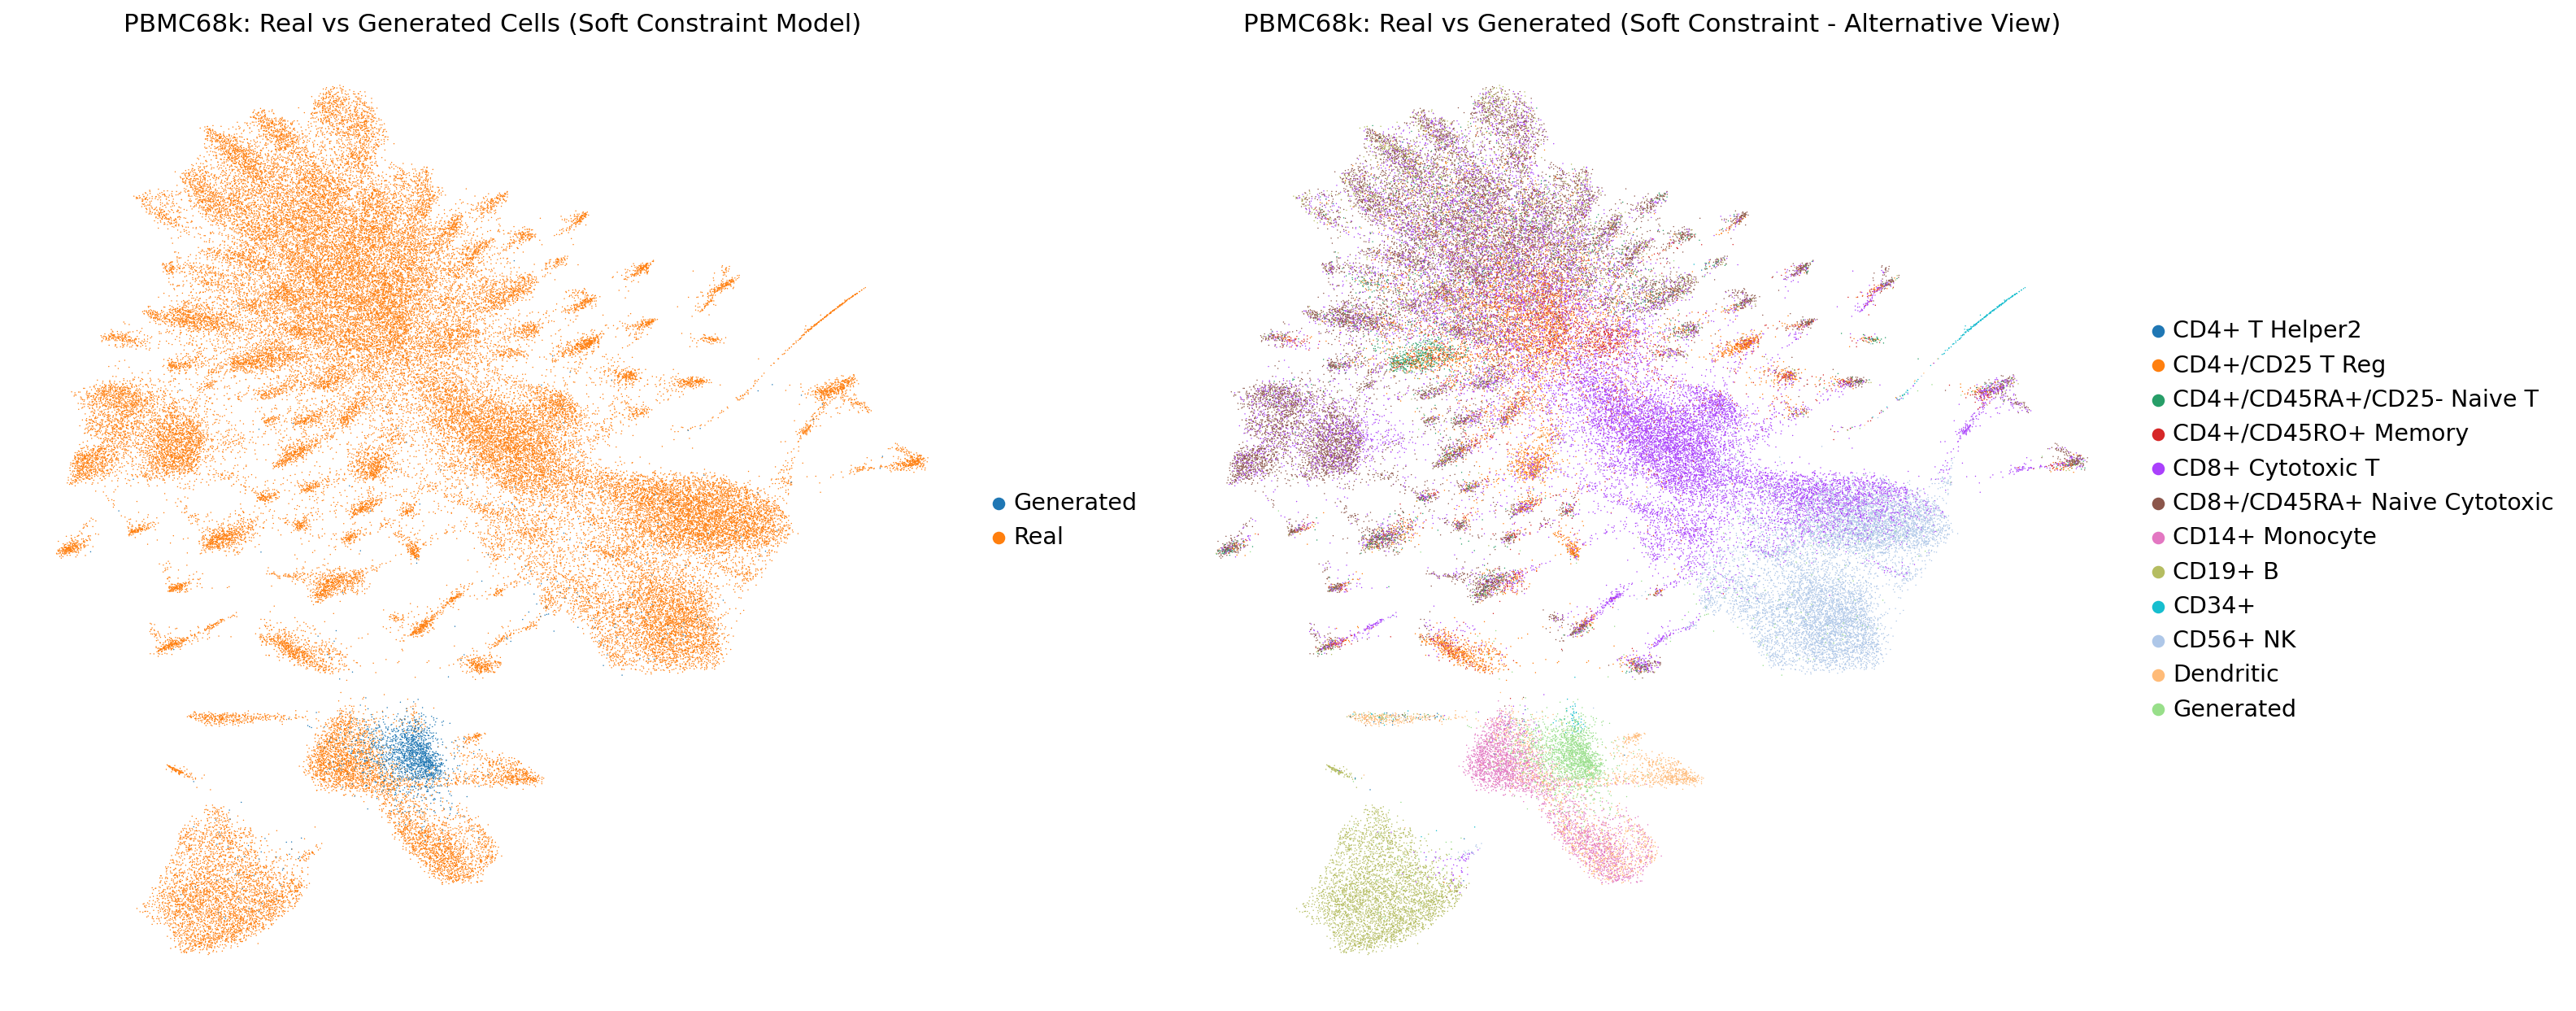

UMAP plots saved to: /home/suzuki/Projects/scDiffusion/exp_result/pbmc68k_soft20251105_reg005_hvg1024/umap_real_vs_generated_soft_constraint.png
UMAP visualization completed!


In [12]:
if 'adata_combined' in locals() and 'X_umap' in adata_combined.obsm:
    print("Creating UMAP visualizations...")
    
    # Create UMAP plots
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot 1: Real vs Generated
    sc.pl.umap(adata_combined, 
               color='cell_origin', 
               ax=axes[0], 
               title='PBMC68k: Real vs Generated Cells (Soft Constraint Model)', 
               frameon=False, 
               show=False)
    
    # Plot 2: Cell Types
    sc.pl.umap(adata_combined, 
               color='celltype', 
               ax=axes[1], 
               title='PBMC68k: Real vs Generated (Soft Constraint - Alternative View)', 
               frameon=False, 
               show=False)
    
    plt.tight_layout()
    plt.show()
    
    # Save the UMAP plots
    output_dir = "/home/suzuki/Projects/scDiffusion/exp_result/pbmc68k_soft20251105_reg005_hvg1024"
    os.makedirs(output_dir, exist_ok=True)
    
    fig.savefig(f"{output_dir}/umap_real_vs_generated_soft_constraint.png", 
                dpi=300, bbox_inches='tight')
    print(f"UMAP plots saved to: {output_dir}/umap_real_vs_generated_soft_constraint.png")
    
    print("UMAP visualization completed!")
    
else:
    print("UMAP results not available. Please run preprocessing first.")

In [13]:
1000*10/60

166.66666666666666

Real subset size: 68579
Generated subset size: 2000


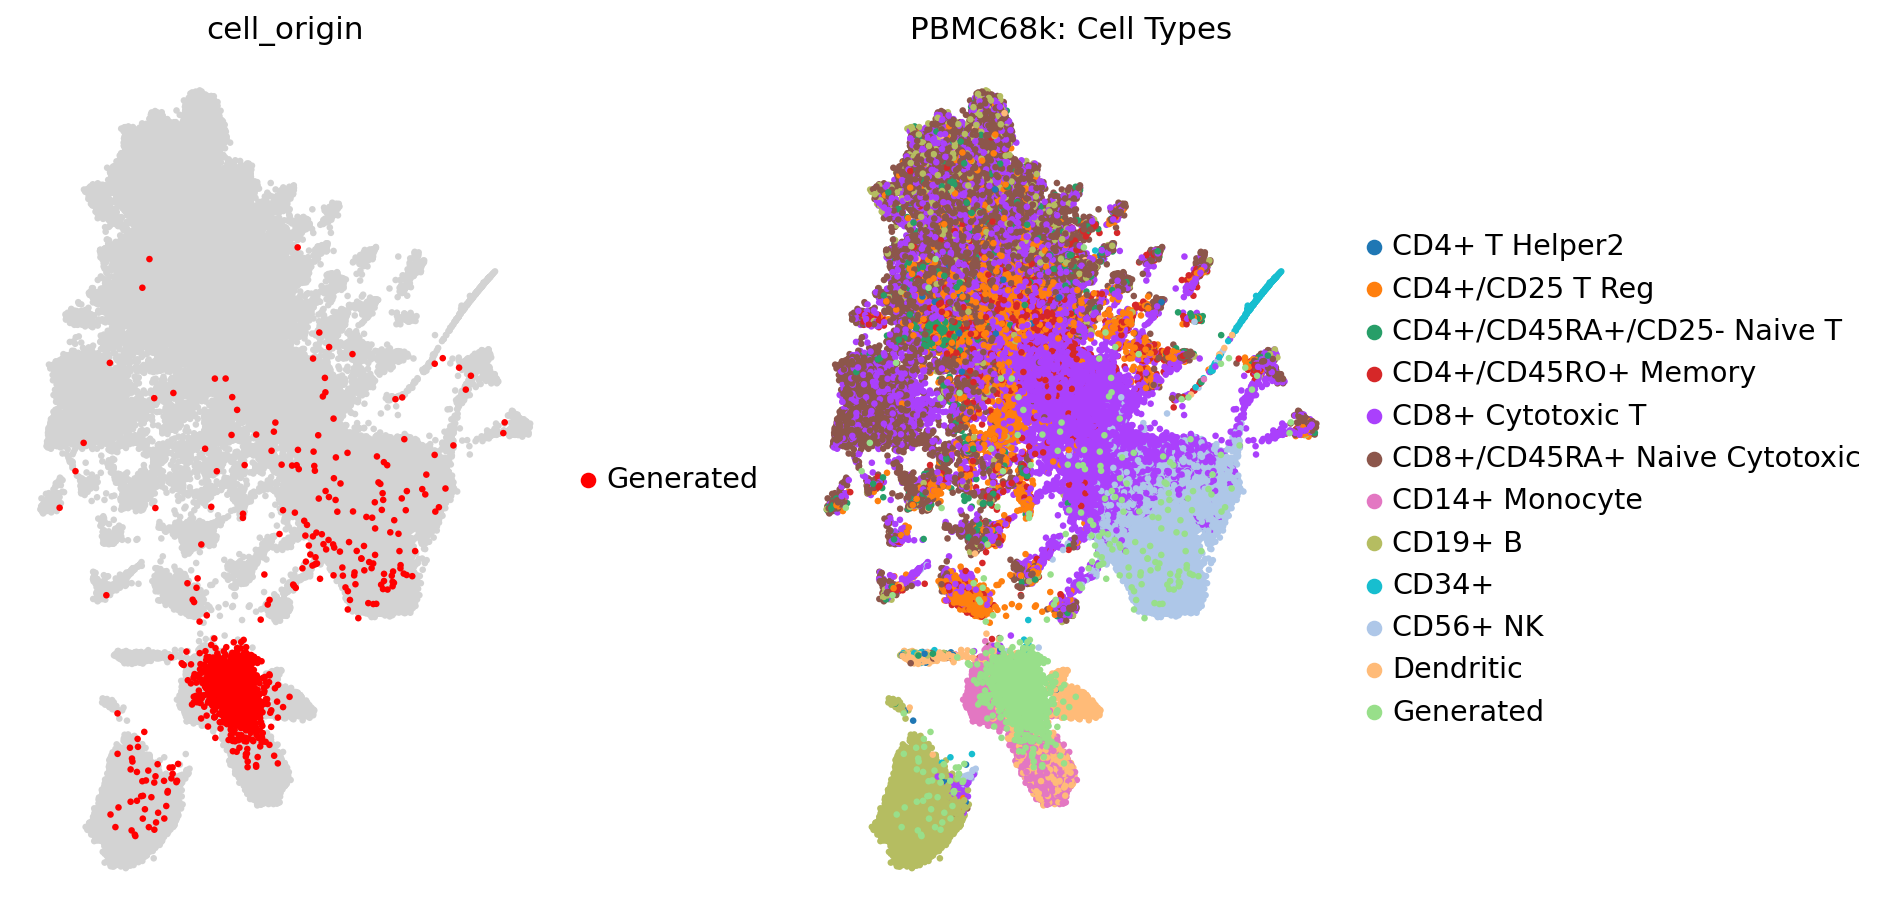

In [14]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

# UMAP 座標があるかチェック
if "X_umap" not in adata_combined.obsm:
    print("X_umap が見つかりません。まず UMAP を計算します。")
    sc.tl.umap(adata_combined)

# サブプロット準備
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Real のみ
mask_real = adata_combined.obs["cell_origin"] == "Real"
adata_real = adata_combined[mask_real].copy()
print("Real subset size:", adata_real.n_obs)

# Generated のみ
mask_gen = adata_combined.obs["cell_origin"] == "Generated"
adata_gen = adata_combined[mask_gen].copy()
print("Generated subset size:", adata_gen.n_obs)

# 描画順：まず Real → 次に Generated 重ね
# （Real を薄灰色で、Generated を強調色で）

# Real をプロット（カテゴリ変数なし、灰色に統一）
if adata_real.n_obs > 0:
    # color を None にすると単色描画
    ax0 = sc.pl.umap(
        adata_real,
        color=None,
        ax=axes[0],
        frameon=False,
        show=False,
        size=35,
        # color_map で色指定は通常 continuous 用なので None を使うか無視
    )
else:
    print("Real データが空なので描画スキップ")

# Generated を上に重ねる
if adata_gen.n_obs > 0:
    # シャッフルして描画順の偏りを減らす
    idx = np.arange(adata_gen.n_obs)
    np.random.shuffle(idx)
    adata_gen = adata_gen[idx].copy()

    sc.pl.umap(
        adata_gen,
        color="cell_origin",
        ax=axes[0],
        frameon=False,
        show=False,
        size=35,
        palette={"Generated": "red"},  # Generated にだけ色を指定
        legend_loc="right margin"
    )
else:
    print("Generated データが空なので描画スキップ")

# 右側プロット：celltype
sc.pl.umap(
    adata_combined,
    color="celltype",
    ax=axes[1],
    title="PBMC68k: Cell Types",
    frameon=False,
    show=False,
    size=35
)

plt.tight_layout()
plt.show()


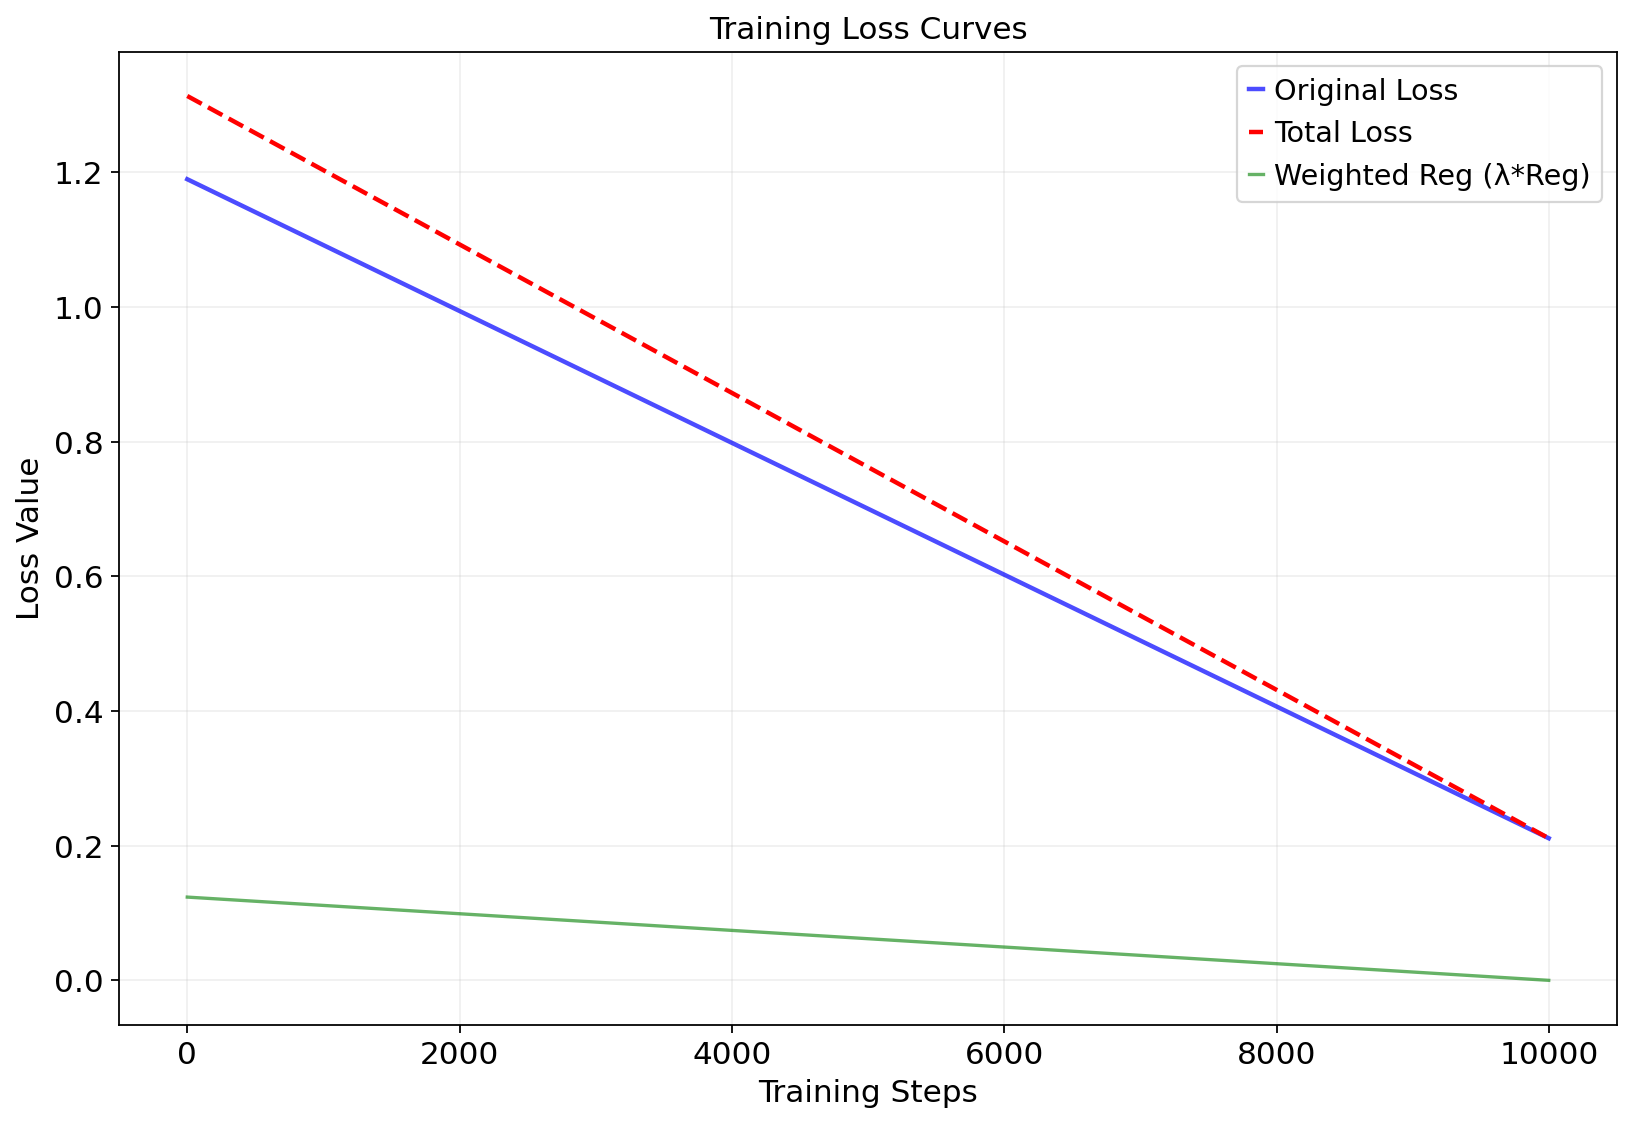

In [20]:
loss_csv_path="/home/suzuki/Projects/scDiffusion/output/diffusion_checkpoint_soft_hvg1024_20251127_008/pbmc68k_soft_20251127_hvg1024/loss_details.csv"
df = pd.read_csv(loss_csv_path)

plt.figure(figsize=(12, 8))
if 'original_loss' in df.columns:
    plt.plot(df['step'], df['original_loss'], label='Original Loss', color='blue', linewidth=2, alpha=0.7)
if 'total_loss' in df.columns:
    plt.plot(df['step'], df['total_loss'], label='Total Loss', color='red', linewidth=2, linestyle='--')

if 'reg_weighted' in df.columns:
    # ax2 = plt.gca().twinx()
    plt.plot(df['step'], df['reg_weighted'], label='Weighted Reg (λ*Reg)', color='green', linewidth=1.5, alpha=0.6)
    # ax2.set_ylabel('Regularization Loss', color='green')
    # ax2.tick_params(axis='y', labelcolor='green')
plt.legend(loc='upper right')
plt.xlabel('Training Steps')
plt.ylabel('Loss Value')
plt.title('Training Loss Curves')
plt.grid(True, alpha=0.3)

## Model Parameter Analysis (Soft Constraint Model)

In [ ]:
# Model Parameter Analysis - Analyze W, b, gamma parameters with mask information
# Load the trained model and analyze parameters based on gene mask

import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the trained model
model_path = "/home/suzuki/Projects/scDiffusion/output/models/pbmc68k_soft_20251106_hvg1024_model.pth"
mask_path = "/home/suzuki/Projects/scDiffusion/exp_script/pbmc68k_soft20251014_hvg1024/pbmc68k_gene_interactions_hvg1024.tsv"

print(f"Loading trained model from: {model_path}")
print(f"Loading gene mask from: {mask_path}")

try:
    # Load model state dict
    model_state = torch.load(model_path, map_location='cpu')
    print("Model loaded successfully!")
    
    # Extract parameters
    W = model_state['W'].numpy() if hasattr(model_state['W'], 'numpy') else model_state['W']
    b = model_state['b'].numpy() if hasattr(model_state['b'], 'numpy') else model_state['b']
    gamma = model_state['gamma'].numpy() if hasattr(model_state['gamma'], 'numpy') else model_state['gamma']
    
    print(f"W shape: {W.shape}")
    print(f"b shape: {b.shape}")
    print(f"gamma shape: {gamma.shape}")
    
    # Load gene mask information
    mask_df = pd.read_csv(mask_path, sep='\t')
    print(f"Mask file loaded with {len(mask_df)} gene interactions")
    print(f"Mask columns: {mask_df.columns.tolist()}")
    
    # Create boolean mask for genes in the interaction file
    # Assuming the mask file has gene indices or names
    if 'gene1_idx' in mask_df.columns and 'gene2_idx' in mask_df.columns:
        # Get unique gene indices from the mask
        masked_genes = set(mask_df['gene1_idx'].tolist() + mask_df['gene2_idx'].tolist())
        print(f"Number of genes in mask: {len(masked_genes)}")
        
        # Create boolean array for masked genes
        gene_mask = np.array([i in masked_genes for i in range(len(b))])
        print(f"Genes in mask: {np.sum(gene_mask)}")
        print(f"Genes not in mask: {np.sum(~gene_mask)}")
    else:
        print("Mask file format not recognized. Please check column names.")
        gene_mask = None
        
except Exception as e:
    print(f"Error loading model or mask: {e}")
    W, b, gamma, gene_mask = None, None, None, None

Loading trained model from: /home/suzuki/Projects/scDiffusion/output/models/pbmc68k_soft_20251106_hvg1024_model.pth
Loading gene mask from: /home/suzuki/Projects/scDiffusion/exp_script/pbmc68k_soft20251014_hvg1024/pbmc68k_gene_interactions_hvg1024.tsv
Error loading model or mask: [Errno 2] No such file or directory: '/home/suzuki/Projects/scDiffusion/output/models/pbmc68k_soft_20251106_hvg1024_model.pth'


In [3]:
# Analyze parameter distributions based on gene mask

In [4]:
if W is not None and b is not None and gamma is not None and gene_mask is not None:
    print("=== PARAMETER ANALYSIS ===")
    
    # Analysis of bias parameter (b)
    print("\n1. Bias parameter (b) analysis:")
    b_masked = b[gene_mask]
    b_not_masked = b[~gene_mask]
    
    print(f"Masked genes bias - Mean: {np.mean(b_masked):.4f}, Std: {np.std(b_masked):.4f}")
    print(f"Non-masked genes bias - Mean: {np.mean(b_not_masked):.4f}, Std: {np.std(b_not_masked):.4f}")
    
    # Statistical test
    from scipy.stats import ttest_ind
    t_stat_b, p_val_b = ttest_ind(b_masked, b_not_masked)
    print(f"T-test for bias: t={t_stat_b:.4f}, p={p_val_b:.6f}")
    
    # Analysis of gamma parameter
    print("\n2. Gamma parameter analysis:")
    gamma_masked = gamma[gene_mask]
    gamma_not_masked = gamma[~gene_mask]
    
    print(f"Masked genes gamma - Mean: {np.mean(gamma_masked):.4f}, Std: {np.std(gamma_masked):.4f}")
    print(f"Non-masked genes gamma - Mean: {np.mean(gamma_not_masked):.4f}, Std: {np.std(gamma_not_masked):.4f}")
    
    t_stat_gamma, p_val_gamma = ttest_ind(gamma_masked, gamma_not_masked)
    print(f"T-test for gamma: t={t_stat_gamma:.4f}, p={p_val_gamma:.6f}")
    
    # Create histograms for bias and gamma parameters
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Bias parameter histograms
    axes[0, 0].hist(b_masked, bins=50, alpha=0.7, label=f'Masked genes (n={len(b_masked)})', color='red')
    axes[0, 0].hist(b_not_masked, bins=50, alpha=0.7, label=f'Non-masked genes (n={len(b_not_masked)})', color='blue')
    axes[0, 0].set_xlabel('Bias parameter (b)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Distribution of Bias Parameters')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Gamma parameter histograms
    axes[0, 1].hist(gamma_masked, bins=50, alpha=0.7, label=f'Masked genes (n={len(gamma_masked)})', color='red')
    axes[0, 1].hist(gamma_not_masked, bins=50, alpha=0.7, label=f'Non-masked genes (n={len(gamma_not_masked)})', color='blue')
    axes[0, 1].set_xlabel('Gamma parameter')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Distribution of Gamma Parameters')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Box plots for comparison
    axes[1, 0].boxplot([b_masked, b_not_masked], labels=['Masked', 'Non-masked'])
    axes[1, 0].set_ylabel('Bias parameter (b)')
    axes[1, 0].set_title('Bias Parameter Comparison')
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].boxplot([gamma_masked, gamma_not_masked], labels=['Masked', 'Non-masked'])
    axes[1, 1].set_ylabel('Gamma parameter')
    axes[1, 1].set_title('Gamma Parameter Comparison')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("Parameters or mask not available. Please check model and mask loading.")

NameError: name 'W' is not defined

In [40]:
# Analysis of W (weight matrix) parameters
if W is not None and gene_mask is not None:
    print("\n=== WEIGHT MATRIX (W) ANALYSIS ===")
    
    # For weight matrix W, we need to consider:
    # 1. Masked-Masked connections (both genes in mask)
    # 2. Non-masked-Non-masked connections (both genes not in mask)  
    # 3. Masked-Non-masked connections (one gene in mask, one not)
    
    # Create masks for different connection types
    masked_indices = np.where(gene_mask)[0]
    non_masked_indices = np.where(~gene_mask)[0]
    
    print(f"Masked gene indices: {len(masked_indices)}")
    print(f"Non-masked gene indices: {len(non_masked_indices)}")
    
    # Extract different types of connections
    # 1. Masked-Masked connections
    W_masked_masked = W[np.ix_(masked_indices, masked_indices)]
    W_mm_flat = W_masked_masked.flatten()
    
    # 2. Non-masked-Non-masked connections
    W_nonmasked_nonmasked = W[np.ix_(non_masked_indices, non_masked_indices)]
    W_nn_flat = W_nonmasked_nonmasked.flatten()
    
    # 3. Masked-Non-masked connections (cross connections)
    W_masked_nonmasked = W[np.ix_(masked_indices, non_masked_indices)]
    W_nonmasked_masked = W[np.ix_(non_masked_indices, masked_indices)]
    W_cross_flat = np.concatenate([W_masked_nonmasked.flatten(), W_nonmasked_masked.flatten()])
    
    print(f"Masked-Masked connections: {len(W_mm_flat)}")
    print(f"Non-masked-Non-masked connections: {len(W_nn_flat)}")
    print(f"Cross connections: {len(W_cross_flat)}")
    
    # Statistical analysis
    print(f"\nMasked-Masked weights - Mean: {np.mean(W_mm_flat):.4f}, Std: {np.std(W_mm_flat):.4f}")
    print(f"Non-masked-Non-masked weights - Mean: {np.mean(W_nn_flat):.4f}, Std: {np.std(W_nn_flat):.4f}")
    print(f"Cross weights - Mean: {np.mean(W_cross_flat):.4f}, Std: {np.std(W_cross_flat):.4f}")
    
    # Statistical tests
    from scipy.stats import ttest_ind
    
    # Compare masked-masked vs non-masked-non-masked
    t_stat_mm_nn, p_val_mm_nn = ttest_ind(W_mm_flat, W_nn_flat)
    print(f"\nMasked-Masked vs Non-masked-Non-masked: t={t_stat_mm_nn:.4f}, p={p_val_mm_nn:.6f}")
    
    # Compare masked-masked vs cross
    t_stat_mm_cross, p_val_mm_cross = ttest_ind(W_mm_flat, W_cross_flat)
    print(f"Masked-Masked vs Cross: t={t_stat_mm_cross:.4f}, p={p_val_mm_cross:.6f}")
    
    # Compare non-masked-non-masked vs cross
    t_stat_nn_cross, p_val_nn_cross = ttest_ind(W_nn_flat, W_cross_flat)
    print(f"Non-masked-Non-masked vs Cross: t={t_stat_nn_cross:.4f}, p={p_val_nn_cross:.6f}")
    
    # Create histograms for W parameters
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Histogram comparison
    axes[0, 0].hist(W_mm_flat, bins=50, alpha=0.7, label=f'Masked-Masked (n={len(W_mm_flat)})', color='red')
    axes[0, 0].hist(W_nn_flat, bins=50, alpha=0.7, label=f'Non-masked-Non-masked (n={len(W_nn_flat)})', color='blue')
    axes[0, 0].hist(W_cross_flat, bins=50, alpha=0.7, label=f'Cross connections (n={len(W_cross_flat)})', color='green')
    axes[0, 0].set_xlabel('Weight values')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Distribution of Weight Matrix Parameters')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Box plot comparison
    axes[0, 1].boxplot([W_mm_flat, W_nn_flat, W_cross_flat], 
                       labels=['M-M', 'N-N', 'Cross'])
    axes[0, 1].set_ylabel('Weight values')
    axes[0, 1].set_title('Weight Parameter Comparison')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Density plots
    axes[1, 0].hist(W_mm_flat, bins=50, density=True, alpha=0.7, label='Masked-Masked', color='red')
    axes[1, 0].hist(W_nn_flat, bins=50, density=True, alpha=0.7, label='Non-masked-Non-masked', color='blue')
    axes[1, 0].hist(W_cross_flat, bins=50, density=True, alpha=0.7, label='Cross connections', color='green')
    axes[1, 0].set_xlabel('Weight values')
    axes[1, 0].set_ylabel('Density')
    axes[1, 0].set_title('Density Distribution of Weight Parameters')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Summary statistics
    axes[1, 1].text(0.1, 0.9, f'Masked-Masked:\nMean: {np.mean(W_mm_flat):.4f}\nStd: {np.std(W_mm_flat):.4f}\nCount: {len(W_mm_flat)}', 
                    transform=axes[1, 1].transAxes, fontsize=10, verticalalignment='top', color='red')
    axes[1, 1].text(0.1, 0.6, f'Non-masked-Non-masked:\nMean: {np.mean(W_nn_flat):.4f}\nStd: {np.std(W_nn_flat):.4f}\nCount: {len(W_nn_flat)}', 
                    transform=axes[1, 1].transAxes, fontsize=10, verticalalignment='top', color='blue')
    axes[1, 1].text(0.1, 0.3, f'Cross connections:\nMean: {np.mean(W_cross_flat):.4f}\nStd: {np.std(W_cross_flat):.4f}\nCount: {len(W_cross_flat)}', 
                    transform=axes[1, 1].transAxes, fontsize=10, verticalalignment='top', color='green')
    axes[1, 1].set_title('Summary Statistics')
    axes[1, 1].set_xticks([])
    axes[1, 1].set_yticks([])
    
    plt.tight_layout()
    plt.show()
    
else:
    print("Weight matrix or mask not available.")

Weight matrix or mask not available.
